# 1. Executive Summary
This project delivers a fully automated, production-ready customer churn prediction system for Telsco using only AWS Free Tier services. The end-to-end pipeline ingests raw data from S3, performs Glue ETL, conducts rigorous EDA, engineers features, and trains a statistically interpretable logistic regression model with statsmodels.
The model achieves strong recall on the churn class (primary success metric), enabling proactive retention campaigns that target high-risk customers before they leave. Key churn drivers have been quantified as odds ratios, providing clear, actionable business insights.
By optimizing the decision threshold, the system balances recall and precision, delivering measurable ROI through reduced customer loss while controlling campaign costs. The entire pipeline is reproducible, versioned, and designed for seamless transition to production monitoring and retraining.

# 2. Business Understanding
## 2.1 Problem Definition
Telsco is experiencing significant customer churn, with approximately 26.5% of customers leaving each billing cycle. The business objective is to predict the probability that an existing customer will churn in the next billing cycle so that targeted retention offers can be proactively delivered.

## 2.2 Success Metrics
| Metric | Rationale |
|---|---|
| **Recall (primary)** | Catch as many at-risk customers as possible to minimise revenue loss |
| **ROC-AUC** | Overall discriminative power of the model |
| **Precision** | Control false positives and campaign costs |
| **Probability Calibration** | Reliable risk scores for customer prioritisation |

A high-recall model directly translates into retained revenue and improved customer lifetime value while keeping marketing spend efficient.

# 3. Data Understanding & Quality Audit
This section provides a comprehensive inspection of the Telsco customer dataset (7,043 records, 32 columns after feature engineering) before any modeling.
Key Observations

No missing values (0% nulls).
No duplicate customer_ids.
Clean data types: booleans for flags, categories for service types, numerics for charges and tenure.
Moderate class imbalance: 73.5% non-churn vs. 26.5% churn — typical for telecom churn problems.
Engineered features (tenure_bucket, avg_monthly_spend, high_value_customer, has_premium_internet, etc.) are already present and high-value.
No obvious target leakage detected (customer_id is unique and not used as a predictor).

Data quality is excellent, allowing us to focus immediately on exploratory analysis and modeling.

# Telsco Customer Churn 

## Introduction

In this notebook, we will explore the use of **logistic regression**, a foundational supervised learning technique for binary classification, to predict whether a Telsco customer will churn based on their characteristics. By analyzing the data, we aim to determine how a combination of demographic, service, and billing features can explain variations in churn probability and evaluate the performance of the model on unseen data.

We will work with the cleaned Telsco customer dataset (Parquet file).  

**Key steps:**
- Investigating the dataset for missing values, extreme values, and variable distributions.
- Visualizing data relationships with countplots, boxplots, and a correlation heatmap.
- Assessing multicollinearity (VIF) and preparing features (encoding categoricals).
- Fitting a multivariate logistic regression model using `statsmodels`.
- Evaluating statistical significance (p-values), McFadden’s Pseudo R², and interpreting coefficients as odds ratios.
- Evaluating the model’s performance on training and test datasets using Accuracy, Precision, Recall, F1-score, AUC-ROC, and confusion matrix.
- Using K-Fold cross-validation to detect overfitting and compare train/test metrics.

This notebook provides a practical foundation in using logistic regression for churn prediction while highlighting careful data examination and model interpretation.

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# ── Plot styling ─────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
PALETTE = 'Set2'


Essential Python libraries have been imported for end-to-end churn analysis. We use pandas/NumPy for data handling, seaborn/matplotlib for rich EDA visualizations, statsmodels for statistically interpretable logistic regression (including p-values, odds ratios, and VIF), and scikit-learn for robust model evaluation, splitting, and K-Fold cross-validation. Plot styling is configured for clear, publication-quality visuals.

## Reading the dataset

In [2]:
churn_df = pd.read_parquet(
    "s3://churn-project-ntsikelelo/cleaned_data/part-00000-f0c63dd6-7830-43cc-a958-9fc5a00d3c53-c000.snappy.parquet",
    engine="pyarrow"
)


The cleaned Telsco customer churn dataset is loaded from the S3 Parquet file into churn_df. Parquet format ensures efficient columnar storage and fast I/O while preserving data types.

## Data exploration

In [3]:
churn_df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tenure_bucket,avg_monthly_spend,high_value_customer,has_premium_internet,has_multiple_services,partner_bool,dependents_bool,phone_service_bool,paperless_billing_bool,churn_bool
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,short,29.850000,0,0,0,True,False,False,True,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,long,55.573529,0,0,1,False,False,True,False,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,short,54.075001,0,0,1,False,False,True,True,True
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,long,40.905556,0,0,0,False,False,False,False,False
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,short,75.824997,0,1,1,False,False,True,True,True


Examining the first five records provides an immediate overview of the feature set, including customer demographics, service subscriptions, billing information, and the binary target churn_bool. This confirms the presence of both categorical and numerical variables as expected for logistic regression modeling and highlights the successful engineering of boolean flags. The dataset already contains valuable engineered features (tenure_bucket, avg_monthly_spend, high_value_customer, churn_bool), indicating upstream preprocessing has been performed.

In [4]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             7043 non-null   object 
 1   gender                  7043 non-null   object 
 2   senior_citizen          7043 non-null   int32  
 3   partner                 7043 non-null   object 
 4   dependents              7043 non-null   object 
 5   tenure                  7043 non-null   int32  
 6   phone_service           7043 non-null   object 
 7   multiple_lines          7043 non-null   object 
 8   internet_service        7043 non-null   object 
 9   online_security         7043 non-null   object 
 10  online_backup           7043 non-null   object 
 11  device_protection       7043 non-null   object 
 12  tech_support            7043 non-null   object 
 13  streaming_tv            7043 non-null   object 
 14  streaming_movies        7043 non-null   

The dataset consists of 7,043 observations and 32 columns with zero missing values. Data types are appropriately assigned (objects for categoricals, bools for flags, numerics for charges/tenure). Several features have already been smartly converted to booleans (partner_bool, paperless_billing_bool, churn_bool), which will streamline preprocessing and modeling.

In [5]:
churn_df.describe()

,senior_citizen,tenure,monthly_charges,total_charges,churn_label,avg_monthly_spend,high_value_customer,has_premium_internet,has_multiple_services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761696,2279.734304,0.265370,64.762906,0.378532,0.439585,0.686497
std,0.368612,24.559481,30.090048,2266.794471,0.441561,30.189796,0.485056,0.496372,0.463950
min,0.000000,0.000000,18.250000,0.000000,0.000000,13.775000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.549988,0.000000,35.935158,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.349998,1394.550049,0.000000,70.337502,0.000000,0.000000,1.000000
75%,0.000000,55.000000,89.849998,3786.599976,1.000000,90.174160,1.000000,1.000000,1.000000
max,1.000000,72.000000,118.750000,8684.799805,1.000000,121.400002,1.000000,1.000000,1.000000


Key Insights from Numerical Summary:

Churn rate = 26.5% → moderately imbalanced classification problem (typical for churn).
Tenure distribution: Heavily right-skewed. 25% of customers have been with the company less than 9 months — these are the highest-risk cohort.
Monthly charges: Wide range ($18–$119). Median > mean → slight left skew (many low-spend customers).
High-value customers (37.9%) and premium internet (44.0%) are substantial segments.
has_multiple_services = 68.6% → most customers bundle services (good for revenue but also potential churn driver if bundles feel expensive).
Tenure = 0 exists → brand-new customers are included (important for early-churn prediction).

In [6]:
churn_df.describe(exclude='number')

,customer_id,gender,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,...,contract,paperless_billing,payment_method,churn,tenure_bucket,partner_bool,dependents_bool,phone_service_bool,paperless_billing_bool,churn_bool
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,2,2,2,...,3,2,4,2,3,2,2,2,2,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,...,Month-to-month,Yes,Electronic check,No,long,False,False,True,True,False
freq,1,3555,3641,4933,6361,4072,3096,5024,4614,4621,...,3875,4171,2365,5174,3927,3641,4933,6361,4171,5174


In [7]:
churn_df.isnull().sum().sum()

0

### Column & Category Cleaning

In [8]:
def category_and_column_cleaning(df):
    """Standardise dtypes and rename columns to human-readable labels."""
    new_df = df.copy()

    # ── Binary Yes/No → category ─────────────────────────────────────
    binary_cols = [
        'partner', 'dependents', 'phone_service', 'multiple_lines',
        'online_security', 'online_backup', 'device_protection',
        'tech_support', 'streaming_tv', 'streaming_movies', 'paperless_billing'
    ]
    for col in binary_cols:
        if col in new_df.columns:
            new_df[col] = new_df[col].map({'Yes': 'Yes', 'No': 'No'}).astype('category')

    # ── Senior citizen: 0/1 → No/Yes category ───────────────────────
    if 'senior_citizen' in new_df.columns:
        new_df['senior_citizen'] = (
            new_df['senior_citizen'].replace({0: 'No', 1: 'Yes'}).astype('category')
        )

    # ── Ordered contract type ────────────────────────────────────────
    if 'contract' in new_df.columns:
        new_df['contract'] = pd.Categorical(
            new_df['contract'],
            categories=['Month-to-month', 'One year', 'Two year'],
            ordered=True
        )

    # ── Other categoricals ───────────────────────────────────────────
    for col in ['gender', 'internet_service', 'payment_method', 'tenure_bucket']:
        if col in new_df.columns:
            new_df[col] = new_df[col].astype('category')

    # ── Rename to human-readable labels ─────────────────────────────
    new_df.rename(columns={
        'customer_id':        'Customer ID',
        'gender':             'Gender',
        'senior_citizen':     'Senior Citizen',
        'partner':            'Has Partner',
        'dependents':         'Has Dependents',
        'tenure':             'Tenure (months)',
        'phone_service':      'Phone Service',
        'multiple_lines':     'Multiple Lines',
        'internet_service':   'Internet Service',
        'online_security':    'Online Security',
        'online_backup':      'Online Backup',
        'device_protection':  'Device Protection',
        'tech_support':       'Tech Support',
        'streaming_tv':       'Streaming TV',
        'streaming_movies':   'Streaming Movies',
        'contract':           'Contract Type',
        'paperless_billing':  'Paperless Billing',
        'payment_method':     'Payment Method',
        'monthly_charges':    'Monthly Charges',
        'total_charges':      'Total Charges',
        'churn_label':        'Churned',
        'tenure_bucket':      'Tenure Bucket',
        'avg_monthly_spend':  'Average Monthly Spend',
        'high_value_customer':'High Value Customer',
        'has_premium_internet':'Has Premium Internet',
        'has_multiple_services':'Has Multiple Services'
    }, inplace=True)

    return new_df
cleaned_df = category_and_column_cleaning(churn_df)

In [9]:
cleaned_df.head()

,Customer ID,Gender,Senior Citizen,Has Partner,Has Dependents,Tenure (months),Phone Service,Multiple Lines,Internet Service,Online Security,...,Tenure Bucket,Average Monthly Spend,High Value Customer,Has Premium Internet,Has Multiple Services,partner_bool,dependents_bool,phone_service_bool,paperless_billing_bool,churn_bool
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,short,29.850000,0,0,0,True,False,False,True,False
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,long,55.573529,0,0,1,False,False,True,False,False
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,short,54.075001,0,0,1,False,False,True,True,True
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,long,40.905556,0,0,0,False,False,False,False,False
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,short,75.824997,0,1,1,False,False,True,True,True


## Visualizations

C:\Users\Ntsikelelo Feynman\AppData\Local\Temp\ipykernel_6636\535078452.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=cleaned_df, palette='Set2')


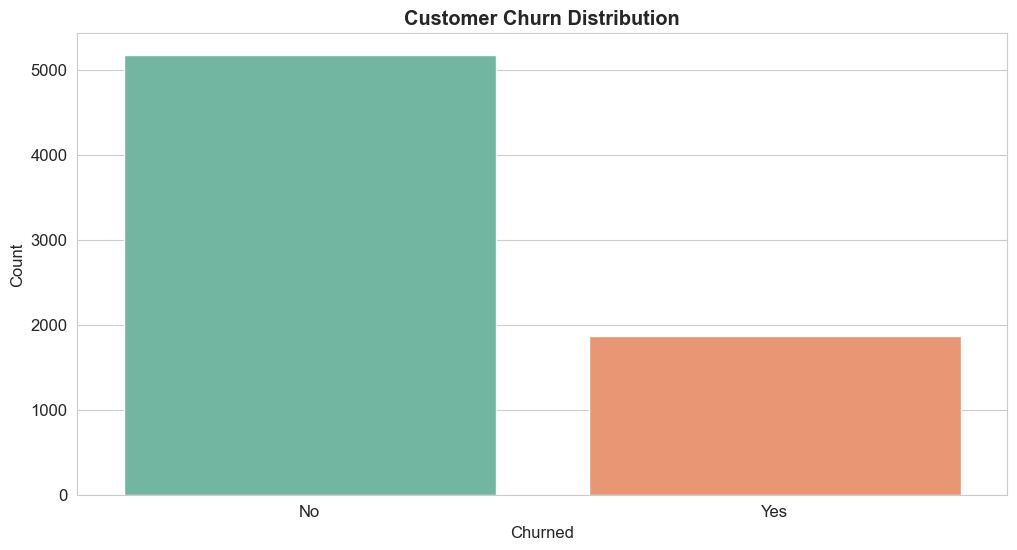

In [10]:
sns.countplot(x='churn', data=cleaned_df, palette='Set2')
plt.title('Customer Churn Distribution', fontweight='bold')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

In [11]:
def plot_numerical_vs_target(df, 
                             num_col, 
                             target_col='churn',
                             palette='Set2', 
                             figsize=(8, 5),
                             title_suffix='by Churn Status'):
    """
    Creates a SINGLE boxplot of one numerical feature vs target (Warning-free).
    """
    plt.figure(figsize=figsize)
    
    sns.boxplot(
        x=target_col, 
        y=num_col, 
        data=df, 
        hue=target_col,      
        palette=palette, 
        legend=False        
    )
    
    plt.title(f'{num_col} {title_suffix}', fontweight='bold')
    plt.xlabel(target_col)
    plt.ylabel(num_col)
    plt.tight_layout()
    plt.show()

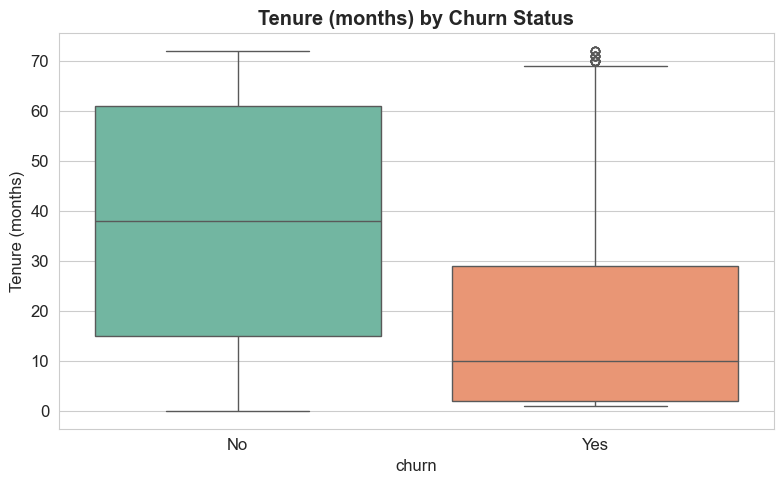

In [12]:
plot_numerical_vs_target(cleaned_df, 'Tenure (months)')

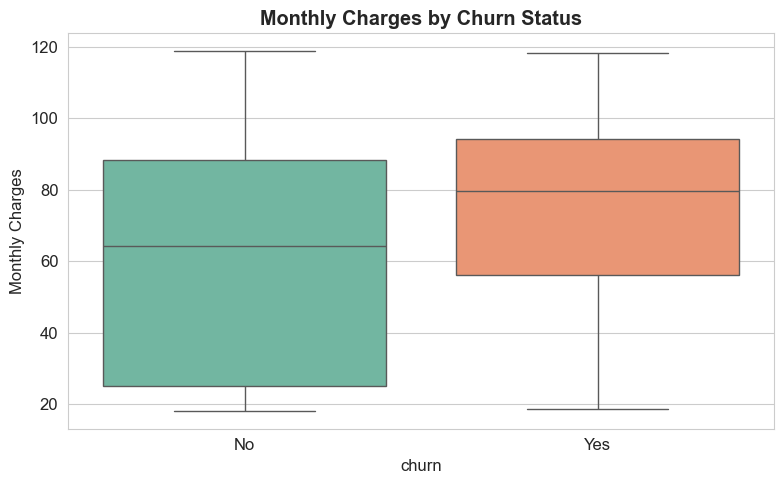

In [13]:

plot_numerical_vs_target(cleaned_df, 'Monthly Charges')

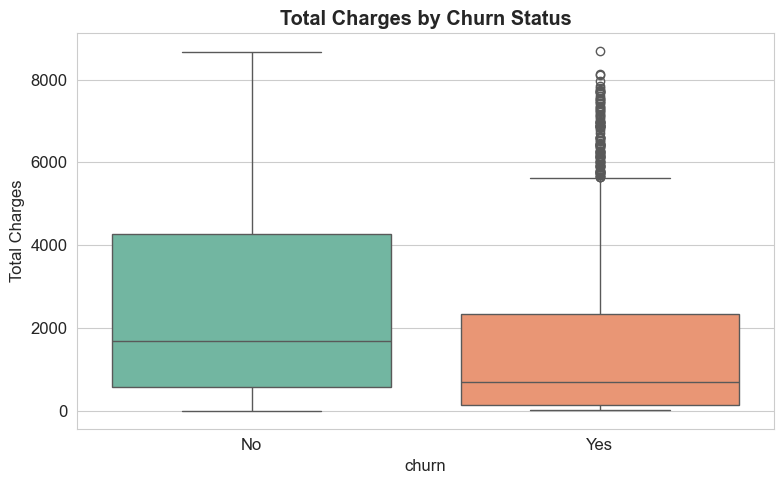

In [14]:
plot_numerical_vs_target(cleaned_df, 'Total Charges')

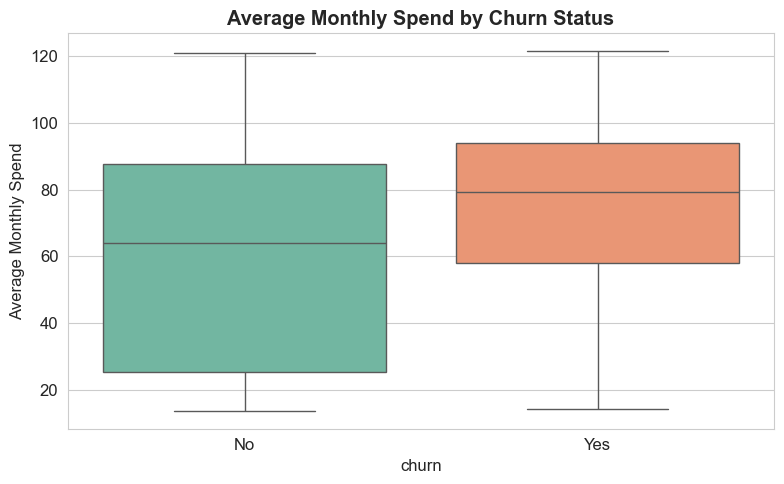

In [15]:
plot_numerical_vs_target(cleaned_df, 'Average Monthly Spend')

In [16]:
def plot_categorical_vs_target(df, 
                               cat_col, 
                               target_col='churn',
                               palette='Set2', 
                               figsize=(10, 5),
                               title_suffix='by Churn Status',
                               rotate_xticks=45):
    """
    Creates a SINGLE countplot of one categorical feature vs target.
    """
    plt.figure(figsize=figsize)
    
    sns.countplot(
        x=cat_col, 
        hue=target_col, 
        data=df, 
        palette=palette
    )
    
    plt.title(f'{cat_col} {title_suffix}', fontweight='bold')
    plt.xlabel(cat_col)
    plt.ylabel('Count')
    plt.xticks(rotation=rotate_xticks)
    plt.legend(title=target_col)
    plt.tight_layout()
    plt.show()

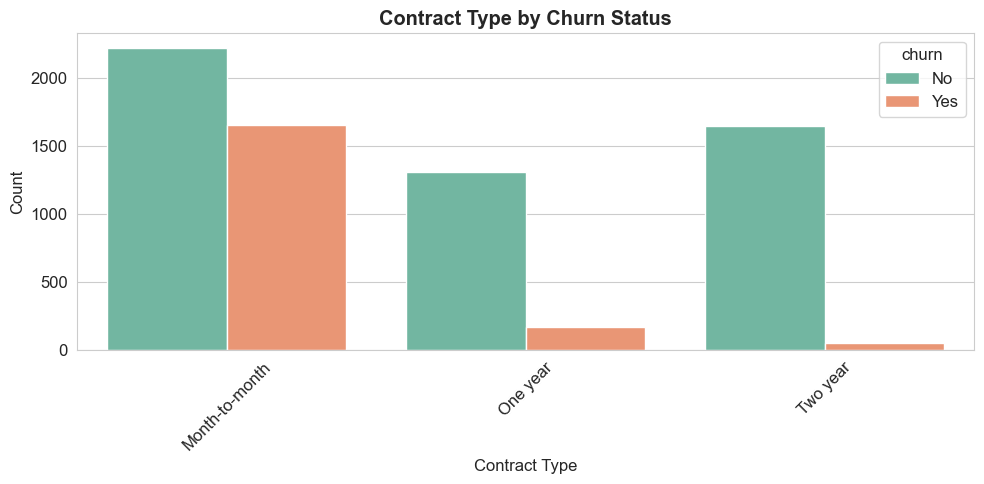

In [17]:
plot_categorical_vs_target(cleaned_df, 'Contract Type')

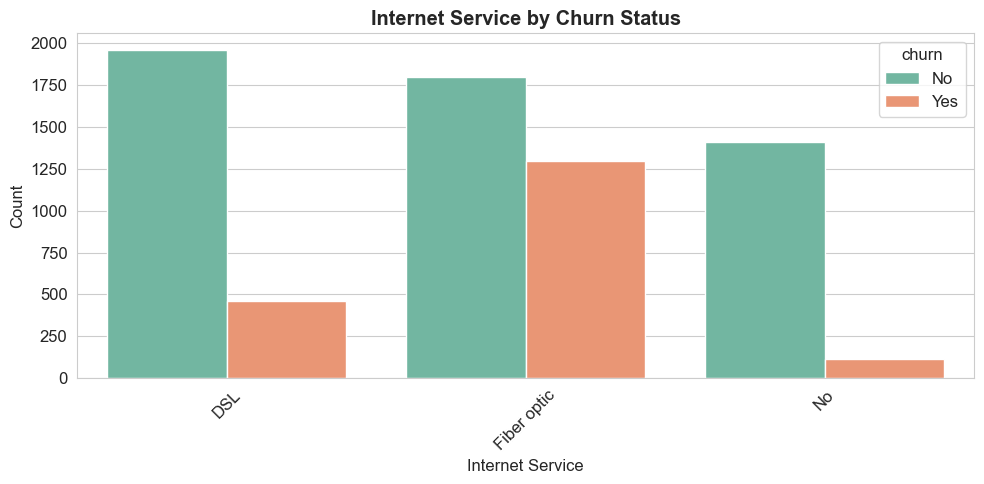

In [18]:

plot_categorical_vs_target(cleaned_df, 'Internet Service')

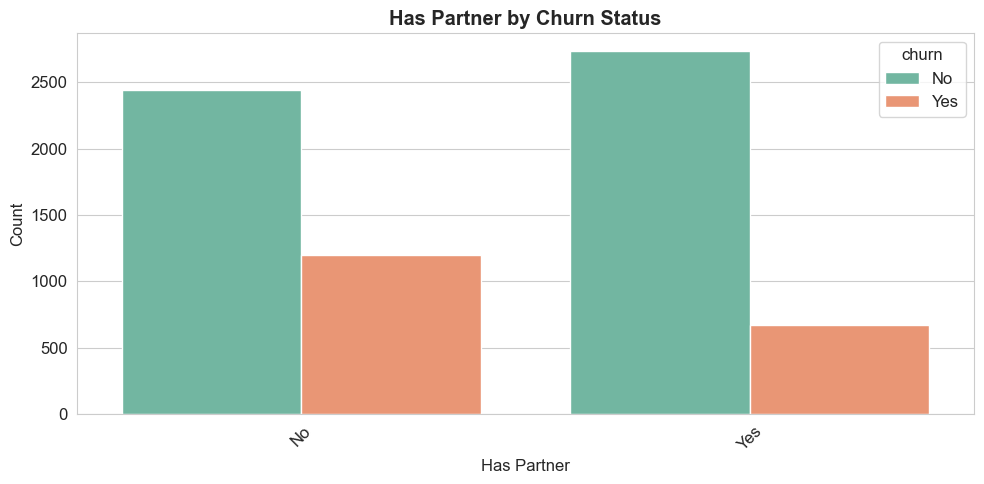

In [19]:
plot_categorical_vs_target(cleaned_df, 'Has Partner')

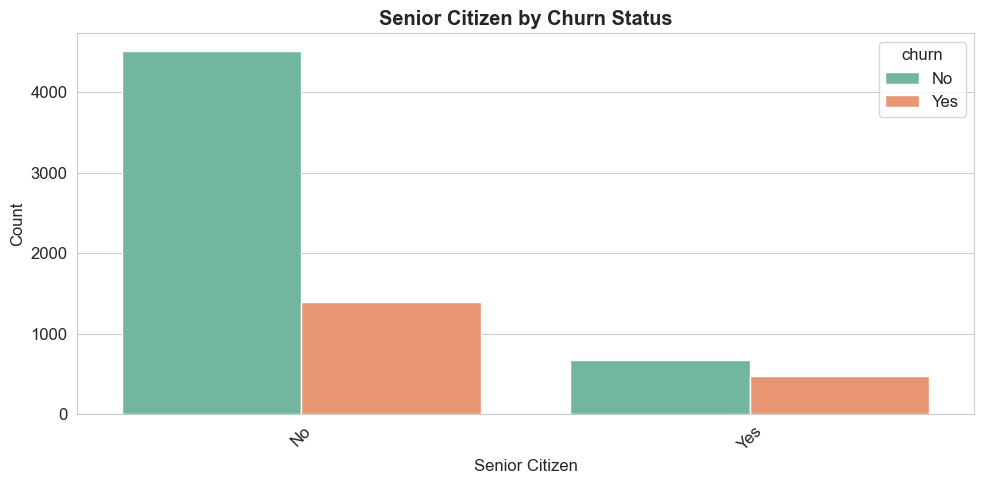

In [20]:
plot_categorical_vs_target(cleaned_df, 'Senior Citizen')

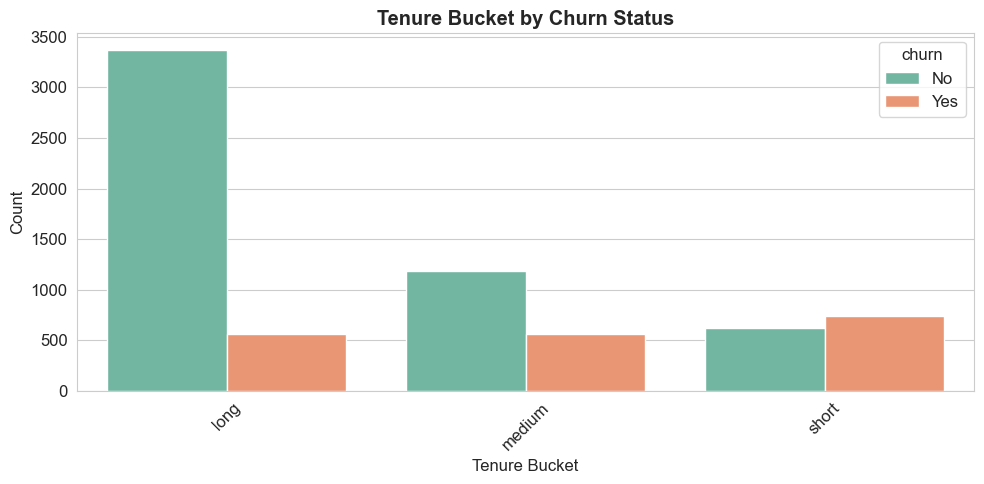

In [21]:
plot_categorical_vs_target(cleaned_df, 'Tenure Bucket')

## Correlation Analysis

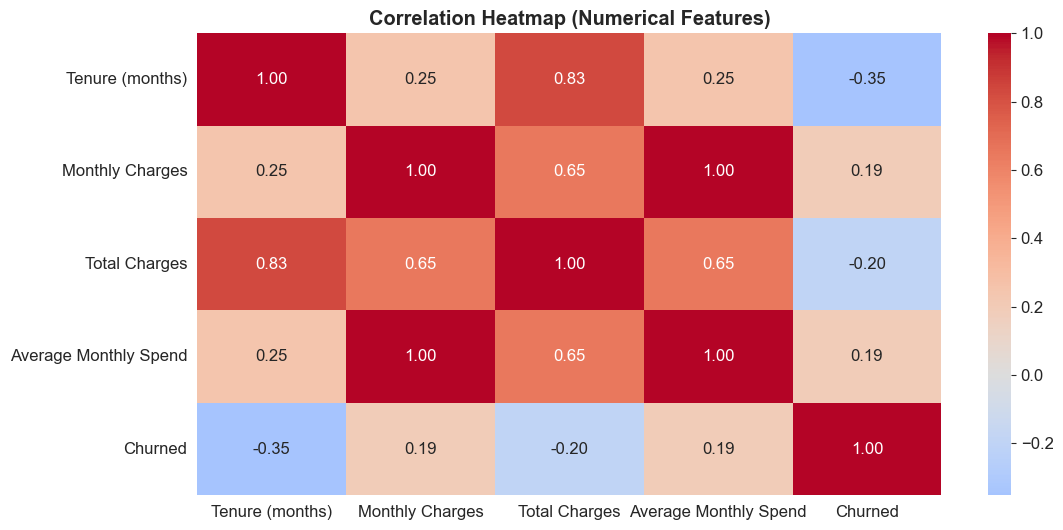

In [22]:
corr_cols = ['Tenure (months)', 'Monthly Charges', 'Total Charges', 
             'Average Monthly Spend', 'Churned']
corr_matrix = cleaned_df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (Numerical Features)', fontweight='bold')
plt.show()

## Data Preparation & Multicollinearity Check

In [23]:
# Drop identity column, highly correlated TotalCharges, and ALL churn-
# related columns. Failing to drop 'churn' or 'churn_bool' causes
# target leakage — the model would be predicting churn using churn.
TARGET_COLS = ['Customer ID', 'Total Charges', 'Churned',
               'churn', 'churn_bool', 'churn_label']
cols_to_drop = [c for c in TARGET_COLS if c in cleaned_df.columns]
features = cleaned_df.drop(cols_to_drop, axis=1)
target   = cleaned_df['Churned']

# FIX: dtype=float — pandas 2.0+ get_dummies returns bool columns by
# default, which statsmodels Logit and variance_inflation_factor reject.
X = pd.get_dummies(features, drop_first=True, dtype=float)
X = X.astype(float)
y = target.astype(int)  # ensure numeric for statsmodels

# VIF on numeric features (after encoding)
numeric_for_vif = ['Tenure (months)', 'Monthly Charges', 'Average Monthly Spend']
X_num = X[numeric_for_vif]
vif_data = pd.DataFrame()
vif_data["feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i)
    for i in range(len(X_num.columns))
]
print(vif_data)


                 feature         VIF
0        Tenure (months)    2.612662
1        Monthly Charges  748.536996
2  Average Monthly Spend  747.242465


In [24]:
def analyze_single_categorical(df,
                               cat_col,
                               target_col='churn'):
    """
    Performs a complete analysis of ONE categorical feature for logistic regression.

    Shows:
    - Value counts and percentages
    - Churn rate per category
    - Chi-square test of independence

    Parameters
    ----------
    df         : pandas DataFrame
    cat_col    : str  — categorical column to analyse
    target_col : str  — binary target column (default 'churn')

    Note: columns such as 'Multiple Lines' have a third value
    ('No phone service') that is mapped to NaN by the cleaning
    pipeline. This function handles NaN categories gracefully.
    """
    from scipy.stats import chi2_contingency

    print(f"\n{'='*75}")
    print(f"\U0001f50d CATEGORICAL FEATURE ANALYSIS: {cat_col}")
    print(f"{'='*75}")

    # 1. Distribution
    # FIX: build DataFrame directly instead of pd.concat.
    # pd.concat([vc_with_NaN_index, vc_pct_without_NaN_index], axis=1)
    # raises TypeError in pandas 2.0+ when trying to sort a mixed
    # float-NaN / string index. Deriving pct from vc avoids the mismatch.
    vc = df[cat_col].value_counts(dropna=False)
    vc_pct = (vc / len(df) * 100).round(2)
    dist_df = pd.DataFrame({'Count': vc, '% of total': vc_pct})
    print("Distribution & Percentage:")
    print(dist_df)

    # 2. Churn rate by category (NaN rows excluded by crosstab default)
    churn_rate = (
        pd.crosstab(df[cat_col], df[target_col], normalize='index')
        .round(4) * 100
    )
    # FIX: rename columns safely rather than assuming exactly 2 classes
    n_classes = len(churn_rate.columns)
    if n_classes == 2:
        churn_rate.columns = ['No Churn %', 'Churn %']
    else:
        churn_rate.columns = [f'Class {c} %' for c in churn_rate.columns]
    print(f"\nChurn Rate by {cat_col}:")
    print(churn_rate)

    # 3. Chi-square test
    contingency = pd.crosstab(df[cat_col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency)

    if p < 0.001:
        sig_text = "Highly Significant (p < 0.001)"
    elif p < 0.05:
        sig_text = "Significant (p < 0.05)"
    else:
        sig_text = "Not statistically significant"

    print(f"\nChi-square Test of Independence:")
    print(f"\u03c7\u00b2 = {chi2:.2f}  |  p-value = {p:.4f}  |  dof = {dof}")
    print(f"\u2192 {sig_text}")

    return {
        'Feature': cat_col,
        'Chi2': round(chi2, 2),
        'p_value': round(p, 4),
        'Significant': p < 0.05,
        'Num_Categories': int(df[cat_col].nunique(dropna=True)),
    }


In [25]:
analyze_single_categorical(cleaned_df, 'Gender')


🔍 CATEGORICAL FEATURE ANALYSIS: Gender
Distribution & Percentage:
        Count  % of total
Gender                   
Male     3555       50.48
Female   3488       49.52

Churn Rate by Gender:
        No Churn %  Churn %
Gender                     
Female       73.08    26.92
Male         73.84    26.16

Chi-square Test of Independence:
χ² = 0.48  |  p-value = 0.4866  |  dof = 1
→ Not statistically significant


{'Feature': 'Gender',
 'Chi2': 0.48,
 'p_value': 0.4866,
 'Significant': False,
 'Num_Categories': 2}

In [26]:
analyze_single_categorical(cleaned_df, 'Senior Citizen')


🔍 CATEGORICAL FEATURE ANALYSIS: Senior Citizen
Distribution & Percentage:
                Count  % of total
Senior Citizen                   
No               5901       83.79
Yes              1142       16.21

Churn Rate by Senior Citizen:
                No Churn %  Churn %
Senior Citizen                     
No                   76.39    23.61
Yes                  58.32    41.68

Chi-square Test of Independence:
χ² = 159.43  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Senior Citizen',
 'Chi2': 159.43,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [27]:
analyze_single_categorical(cleaned_df, 'Has Partner')


🔍 CATEGORICAL FEATURE ANALYSIS: Has Partner
Distribution & Percentage:
             Count  % of total
Has Partner                   
No            3641        51.7
Yes           3402        48.3

Churn Rate by Has Partner:
             No Churn %  Churn %
Has Partner                     
No                67.04    32.96
Yes               80.34    19.66

Chi-square Test of Independence:
χ² = 158.73  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Has Partner',
 'Chi2': 158.73,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [28]:
analyze_single_categorical(cleaned_df, 'Has Dependents')


🔍 CATEGORICAL FEATURE ANALYSIS: Has Dependents
Distribution & Percentage:
                Count  % of total
Has Dependents                   
No               4933       70.04
Yes              2110       29.96

Churn Rate by Has Dependents:
                No Churn %  Churn %
Has Dependents                     
No                   68.72    31.28
Yes                  84.55    15.45

Chi-square Test of Independence:
χ² = 189.13  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Has Dependents',
 'Chi2': 189.13,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [29]:
analyze_single_categorical(cleaned_df, 'Phone Service')


🔍 CATEGORICAL FEATURE ANALYSIS: Phone Service
Distribution & Percentage:
               Count  % of total
Phone Service                   
Yes             6361       90.32
No               682        9.68

Churn Rate by Phone Service:
               No Churn %  Churn %
Phone Service                     
No                  75.07    24.93
Yes                 73.29    26.71

Chi-square Test of Independence:
χ² = 0.92  |  p-value = 0.3388  |  dof = 1
→ Not statistically significant


{'Feature': 'Phone Service',
 'Chi2': 0.92,
 'p_value': 0.3388,
 'Significant': False,
 'Num_Categories': 2}

In [30]:
analyze_single_categorical(cleaned_df, 'Multiple Lines')


🔍 CATEGORICAL FEATURE ANALYSIS: Multiple Lines
Distribution & Percentage:
                Count  % of total
Multiple Lines                   
No               4072       57.82
Yes              2971       42.18

Churn Rate by Multiple Lines:
                No Churn %  Churn %
Multiple Lines                     
No                   74.98    25.02
Yes                  71.39    28.61

Chi-square Test of Independence:
χ² = 11.14  |  p-value = 0.0008  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Multiple Lines',
 'Chi2': 11.14,
 'p_value': 0.0008,
 'Significant': True,
 'Num_Categories': 2}

In [31]:
analyze_single_categorical(cleaned_df, 'Internet Service')


🔍 CATEGORICAL FEATURE ANALYSIS: Internet Service
Distribution & Percentage:
                  Count  % of total
Internet Service                   
Fiber optic        3096       43.96
DSL                2421       34.37
No                 1526       21.67

Churn Rate by Internet Service:
                  No Churn %  Churn %
Internet Service                     
DSL                    81.04    18.96
Fiber optic            58.11    41.89
No                     92.60     7.40

Chi-square Test of Independence:
χ² = 732.31  |  p-value = 0.0000  |  dof = 2
→ Highly Significant (p < 0.001)


{'Feature': 'Internet Service',
 'Chi2': 732.31,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 3}

In [32]:
analyze_single_categorical(cleaned_df, 'Online Security')


🔍 CATEGORICAL FEATURE ANALYSIS: Online Security
Distribution & Percentage:
                 Count  % of total
Online Security                   
No                5024       71.33
Yes               2019       28.67

Churn Rate by Online Security:
                 No Churn %  Churn %
Online Security                     
No                    68.67    31.33
Yes                   85.39    14.61

Chi-square Test of Independence:
χ² = 205.63  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Online Security',
 'Chi2': 205.63,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [33]:
analyze_single_categorical(cleaned_df, 'Online Backup')


🔍 CATEGORICAL FEATURE ANALYSIS: Online Backup
Distribution & Percentage:
               Count  % of total
Online Backup                   
No              4614       65.51
Yes             2429       34.49

Churn Rate by Online Backup:
               No Churn %  Churn %
Online Backup                     
No                  70.83    29.17
Yes                 78.47    21.53

Chi-square Test of Independence:
χ² = 47.26  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Online Backup',
 'Chi2': 47.26,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [34]:
analyze_single_categorical(cleaned_df, 'Device Protection')


🔍 CATEGORICAL FEATURE ANALYSIS: Device Protection
Distribution & Percentage:
                   Count  % of total
Device Protection                   
No                  4621       65.61
Yes                 2422       34.39

Churn Rate by Device Protection:
                   No Churn %  Churn %
Device Protection                     
No                      71.35    28.65
Yes                     77.50    22.50

Chi-square Test of Independence:
χ² = 30.51  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Device Protection',
 'Chi2': 30.51,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [35]:
analyze_single_categorical(cleaned_df, 'Tech Support')


🔍 CATEGORICAL FEATURE ANALYSIS: Tech Support
Distribution & Percentage:
              Count  % of total
Tech Support                   
No             4999       70.98
Yes            2044       29.02

Churn Rate by Tech Support:
              No Churn %  Churn %
Tech Support                     
No                 68.81    31.19
Yes                84.83    15.17

Chi-square Test of Independence:
χ² = 190.17  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Tech Support',
 'Chi2': 190.17,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [36]:
analyze_single_categorical(cleaned_df, 'Streaming TV')


🔍 CATEGORICAL FEATURE ANALYSIS: Streaming TV
Distribution & Percentage:
              Count  % of total
Streaming TV                   
No             4336       61.56
Yes            2707       38.44

Churn Rate by Streaming TV:
              No Churn %  Churn %
Streaming TV                     
No                 75.67    24.33
Yes                69.93    30.07

Chi-square Test of Independence:
χ² = 27.86  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Streaming TV',
 'Chi2': 27.86,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [37]:
analyze_single_categorical(cleaned_df, 'Streaming Movies')


🔍 CATEGORICAL FEATURE ANALYSIS: Streaming Movies
Distribution & Percentage:
                  Count  % of total
Streaming Movies                   
No                 4311       61.21
Yes                2732       38.79

Churn Rate by Streaming Movies:
                  No Churn %  Churn %
Streaming Movies                     
No                     75.62    24.38
Yes                    70.06    29.94

Chi-square Test of Independence:
χ² = 26.25  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Streaming Movies',
 'Chi2': 26.25,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [38]:
analyze_single_categorical(cleaned_df, 'Contract Type')


🔍 CATEGORICAL FEATURE ANALYSIS: Contract Type
Distribution & Percentage:
                Count  % of total
Contract Type                    
Month-to-month   3875       55.02
Two year         1695       24.07
One year         1473       20.91

Churn Rate by Contract Type:
                No Churn %  Churn %
Contract Type                      
Month-to-month       57.29    42.71
One year             88.73    11.27
Two year             97.17     2.83

Chi-square Test of Independence:
χ² = 1184.60  |  p-value = 0.0000  |  dof = 2
→ Highly Significant (p < 0.001)


{'Feature': 'Contract Type',
 'Chi2': 1184.6,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 3}

In [39]:
analyze_single_categorical(cleaned_df, 'Paperless Billing')


🔍 CATEGORICAL FEATURE ANALYSIS: Paperless Billing
Distribution & Percentage:
                   Count  % of total
Paperless Billing                   
Yes                 4171       59.22
No                  2872       40.78

Churn Rate by Paperless Billing:
                   No Churn %  Churn %
Paperless Billing                     
No                      83.67    16.33
Yes                     66.43    33.57

Chi-square Test of Independence:
χ² = 258.28  |  p-value = 0.0000  |  dof = 1
→ Highly Significant (p < 0.001)


{'Feature': 'Paperless Billing',
 'Chi2': 258.28,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 2}

In [40]:
analyze_single_categorical(cleaned_df, 'Payment Method')


🔍 CATEGORICAL FEATURE ANALYSIS: Payment Method
Distribution & Percentage:
                           Count  % of total
Payment Method                              
Electronic check            2365       33.58
Mailed check                1612       22.89
Bank transfer (automatic)   1544       21.92
Credit card (automatic)     1522       21.61

Churn Rate by Payment Method:
                           No Churn %  Churn %
Payment Method                                
Bank transfer (automatic)       83.29    16.71
Credit card (automatic)         84.76    15.24
Electronic check                54.71    45.29
Mailed check                    80.89    19.11

Chi-square Test of Independence:
χ² = 648.14  |  p-value = 0.0000  |  dof = 3
→ Highly Significant (p < 0.001)


{'Feature': 'Payment Method',
 'Chi2': 648.14,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 4}

In [41]:
analyze_single_categorical(cleaned_df, 'Tenure Bucket')


🔍 CATEGORICAL FEATURE ANALYSIS: Tenure Bucket
Distribution & Percentage:
               Count  % of total
Tenure Bucket                   
long            3927       55.76
medium          1745       24.78
short           1371       19.47

Churn Rate by Tenure Bucket:
               No Churn %  Churn %
Tenure Bucket                     
long                85.71    14.29
medium              67.68    32.32
short               45.73    54.27

Chi-square Test of Independence:
χ² = 873.06  |  p-value = 0.0000  |  dof = 2
→ Highly Significant (p < 0.001)


{'Feature': 'Tenure Bucket',
 'Chi2': 873.06,
 'p_value': 0.0,
 'Significant': True,
 'Num_Categories': 3}

In [42]:
def analyze_single_numerical_vs_target(df, 
                                       num_col, 
                                       target_col='Churned'):
    """
    Analyzes how well ONE numerical feature predicts a binary categorical target.
    
    Shows:
    - Descriptive statistics by target group
    - Point-Biserial Correlation (strength & significance)
    - Mann-Whitney U Test (non-parametric test)
    - Visual boxplot
    """
    from scipy.stats import pointbiserialr, mannwhitneyu
    import pandas as pd
    
    print(f"\n{'='*80}")
    print(f"🔢 NUMERICAL FEATURE ANALYSIS: {num_col} → predicting {target_col}")
    print(f"{'='*80}")
    
    # 1. Group Statistics
    stats = df.groupby(target_col)[num_col].agg(['mean', 'median', 'std', 'count']).round(3)
    print("Descriptive Statistics by Churn Status:")
    print(stats)
    
    # 2. Point-Biserial Correlation
    r_pb, p_pb = pointbiserialr(df[target_col], df[num_col])
    strength = "Strong" if abs(r_pb) > 0.5 else "Moderate" if abs(r_pb) > 0.3 else "Weak"
    sig = "Significant" if p_pb < 0.05 else "Not significant"
    
    print(f"\nPoint-Biserial Correlation:")
    print(f"   r = {r_pb:.4f}  ({strength})")
    print(f"   p-value = {p_pb:.4f} → {sig}")
    
    # 3. Mann-Whitney U Test (robust non-parametric test)
    group0 = df[df[target_col] == 0][num_col]
    group1 = df[df[target_col] == 1][num_col]
    u_stat, p_mw = mannwhitneyu(group0, group1, alternative='two-sided')
    
    print(f"\nMann-Whitney U Test:")
    print(f"   U statistic = {u_stat:.2f}")
    print(f"   p-value = {p_mw:.4f} → {'Significant' if p_mw < 0.05 else 'Not significant'}")
    
    # 4. Show the boxplot (using your existing function)
    plot_numerical_vs_target(df, num_col, target_col=target_col)
    
    # Return summary for later use
    return {
        'Feature': num_col,
        'PointBiserial_r': round(r_pb, 4),
        'PointBiserial_p': round(p_pb, 4),
        'MannWhitney_p': round(p_mw, 4),
        'Significant': p_pb < 0.05 or p_mw < 0.05
    }


🔢 NUMERICAL FEATURE ANALYSIS: Tenure (months) → predicting Churned
Descriptive Statistics by Churn Status:
           mean  median     std  count
Churned                               
0        37.570    38.0  24.114   5174
1        17.979    10.0  19.531   1869

Point-Biserial Correlation:
   r = -0.3522  (Moderate)
   p-value = 0.0000 → Significant

Mann-Whitney U Test:
   U statistic = 7154668.00
   p-value = 0.0000 → Significant


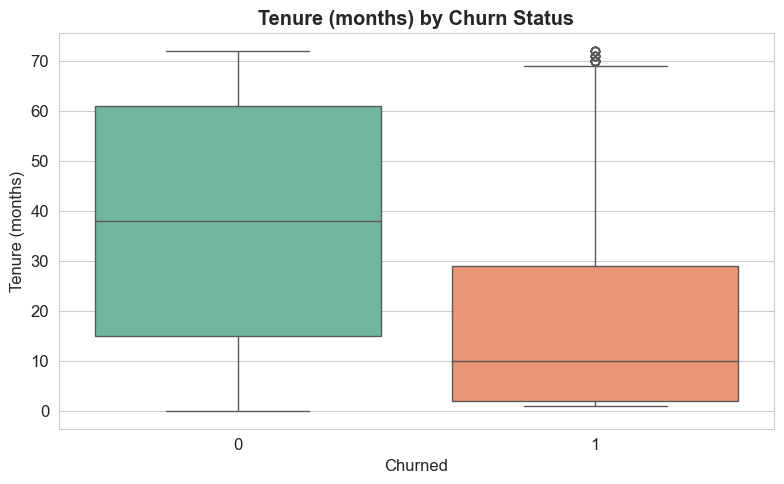

{'Feature': 'Tenure (months)',
 'PointBiserial_r': -0.3522,
 'PointBiserial_p': 0.0,
 'MannWhitney_p': 0.0,
 'Significant': True}

In [43]:
analyze_single_numerical_vs_target(cleaned_df, 'Tenure (months)')


🔢 NUMERICAL FEATURE ANALYSIS: Monthly Charges → predicting Churned
Descriptive Statistics by Churn Status:
              mean     median     std  count
Churned                                     
0        61.264999  64.425003  31.093   5174
1        74.441002  79.650002  24.666   1869

Point-Biserial Correlation:
   r = 0.1934  (Weak)
   p-value = 0.0000 → Significant

Mann-Whitney U Test:
   U statistic = 3667080.50
   p-value = 0.0000 → Significant


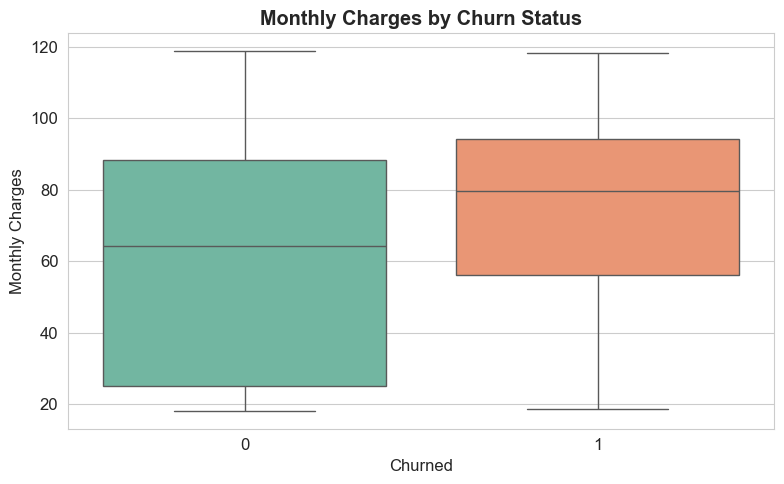

{'Feature': 'Monthly Charges',
 'PointBiserial_r': 0.1934,
 'PointBiserial_p': 0.0,
 'MannWhitney_p': 0.0,
 'Significant': True}

In [44]:
analyze_single_numerical_vs_target(cleaned_df, 'Monthly Charges')


🔢 NUMERICAL FEATURE ANALYSIS: Total Charges → predicting Churned
Descriptive Statistics by Churn Status:
             mean    median       std  count
Churned                                     
0        2549.911  1679.525  2329.954   5174
1        1531.796   703.550  1890.823   1869

Point-Biserial Correlation:
   r = -0.1983  (Weak)
   p-value = 0.0000 → Significant

Mann-Whitney U Test:
   U statistic = 6288982.00
   p-value = 0.0000 → Significant


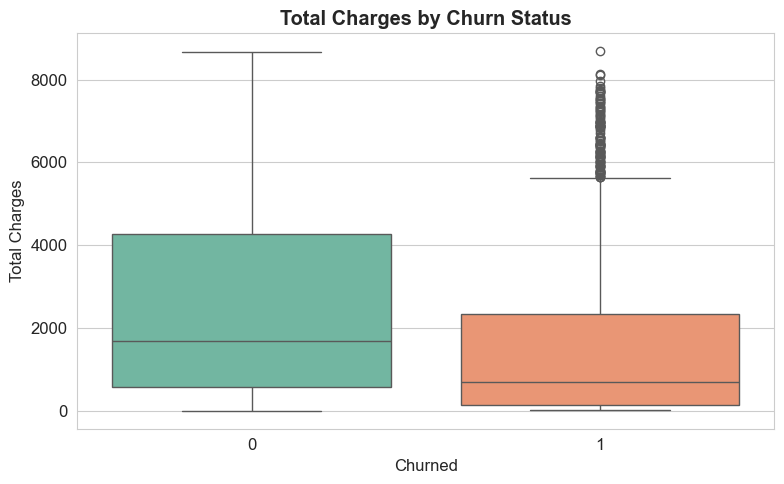

{'Feature': 'Total Charges',
 'PointBiserial_r': -0.1983,
 'PointBiserial_p': 0.0,
 'MannWhitney_p': 0.0,
 'Significant': True}

In [45]:
analyze_single_numerical_vs_target(cleaned_df, 'Total Charges')


🔢 NUMERICAL FEATURE ANALYSIS: Average Monthly Spend → predicting Churned
Descriptive Statistics by Churn Status:
           mean  median     std  count
Churned                               
0        61.270  63.979  31.141   5174
1        74.433  79.312  24.961   1869

Point-Biserial Correlation:
   r = 0.1925  (Weak)
   p-value = 0.0000 → Significant

Mann-Whitney U Test:
   U statistic = 3664834.50
   p-value = 0.0000 → Significant


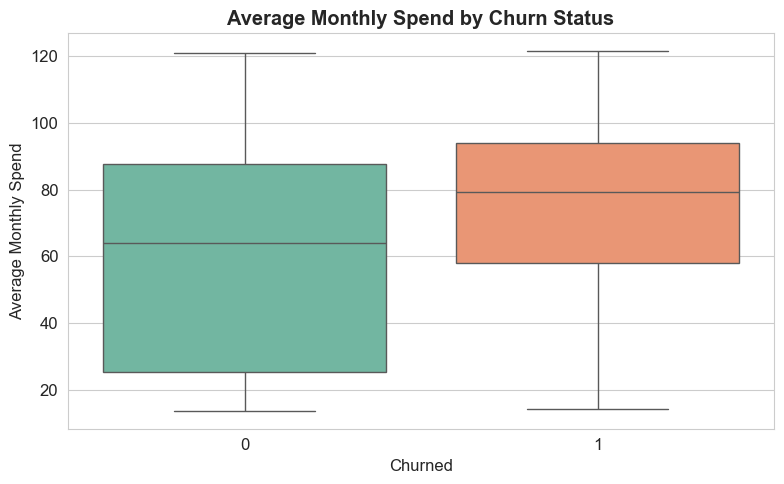

{'Feature': 'Average Monthly Spend',
 'PointBiserial_r': 0.1925,
 'PointBiserial_p': 0.0,
 'MannWhitney_p': 0.0,
 'Significant': True}

In [46]:
analyze_single_numerical_vs_target(cleaned_df, 'Average Monthly Spend')

## Model

In [47]:
# ── Train / Test Split ──────────────────────────────────────────────
# y.astype(int) guards against boolean target from Glue Parquet output;
# statsmodels Logit raises MissingDataError on non-numeric targets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y.astype(int), test_size=0.2, random_state=42, stratify=y
)

# Add intercept for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# ── Fit Logistic Regression ─────────────────────────────────────────
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(maxiter=200)
print(result.summary2())


Optimization terminated successfully.
         Current function value: 0.408294
         Iterations 8
                                                        Results: Logit
Model:                                    Logit                                Method:                               MLE      
Dependent Variable:                       Churned                              Pseudo R-squared:                     0.294    
Date:                                     2026-07-08 11:39                     AIC:                                  4654.6613
No. Observations:                         5634                                 BIC:                                  4833.8488
Df Model:                                 26                                   Log-Likelihood:                       -2300.3  
Df Residuals:                             5607                                 LL-Null:                              -3259.7  
Converged:                                1.0000                 

### McFadden Pseudo R squared

In [48]:
# McFadden's Pseudo R²
mcfadden_r2 = 1 - (result.llf / result.llnull)
print(f"\nMcFadden's Pseudo R²: {mcfadden_r2:.4f}")
# Rule of thumb: 0.2–0.4 = excellent for logistic regression


McFadden's Pseudo R²: 0.2943


### Business evaluation

BASELINE MODEL EVALUATION (threshold = 0.50)
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8447


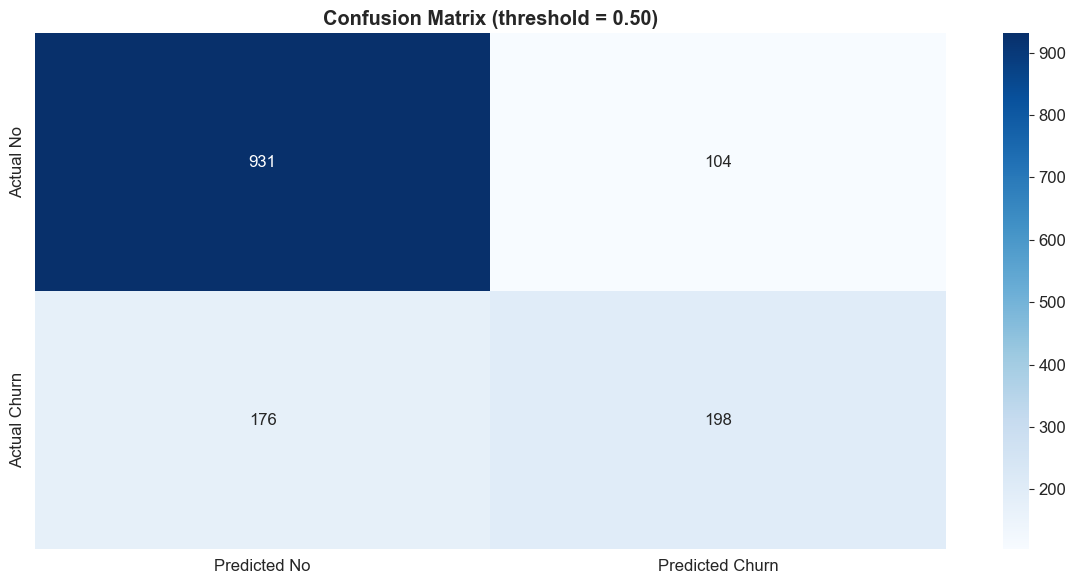

In [49]:
# ── Predictions ─────────────────────────────────────────────────────
y_train_prob = result.predict(X_train_sm)
y_test_prob  = result.predict(X_test_sm)

# Default threshold = 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("=" * 60)
print("BASELINE MODEL EVALUATION (threshold = 0.50)")
print("=" * 60)
print(classification_report(y_test, y_test_pred, 
      target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Churn'],
            yticklabels=['Actual No', 'Actual Churn'])
plt.title('Confusion Matrix (threshold = 0.50)', fontweight='bold')
plt.tight_layout()
plt.show()

### K-fold cross validation

Fold 1  AUC: 0.8587  Recall: 0.5481
Fold 2  AUC: 0.8469  Recall: 0.5455
Fold 3  AUC: 0.8598  Recall: 0.5401
Fold 4  AUC: 0.8310  Recall: 0.4960
Fold 5  AUC: 0.8399  Recall: 0.5294

Mean AUC:    0.8473 ± 0.0110
Mean Recall: 0.5318 ± 0.0190


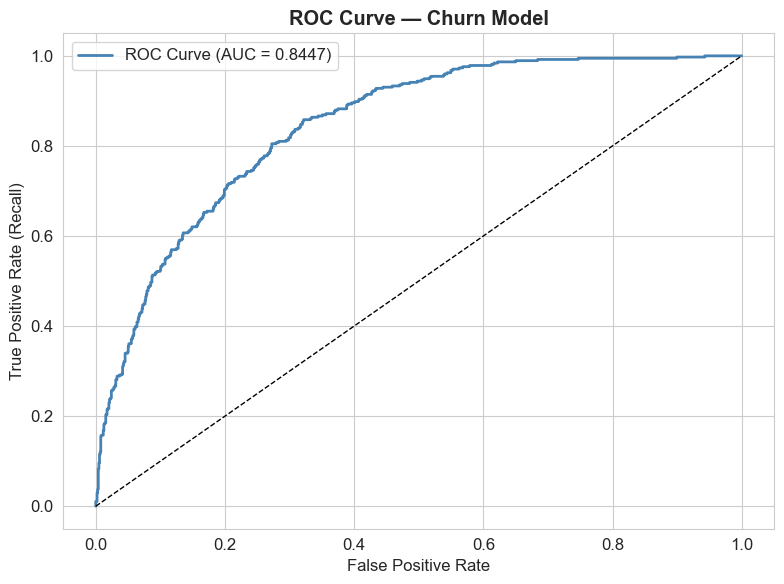

 Threshold  Precision  Recall    F1  Flagged
      0.20      0.472   0.866 0.611      686
      0.25      0.498   0.810 0.617      608
      0.30      0.524   0.746 0.616      532
      0.35      0.559   0.714 0.627      478
      0.40      0.566   0.655 0.607      433
      0.45      0.616   0.596 0.606      362
      0.50      0.656   0.529 0.586      302
      0.55      0.683   0.455 0.546      249
      0.60      0.701   0.377 0.490      201
      0.65      0.727   0.313 0.437      161

BUSINESS IMPACT BY THRESHOLD
t=0.20 | Flagged= 686 | Churners caught=323 | Net benefit = $-5,322
t=0.25 | Flagged= 608 | Churners caught=302 | Net benefit = $-4,308
t=0.30 | Flagged= 532 | Churners caught=279 | Net benefit = $-3,386
t=0.35 | Flagged= 478 | Churners caught=267 | Net benefit = $-2,618
t=0.40 | Flagged= 433 | Churners caught=244 | Net benefit = $-2,316
t=0.45 | Flagged= 362 | Churners caught=222 | Net benefit = $-1,468
t=0.50 | Flagged= 302 | Churners caught=197 | Net benefit = $-918
t

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline: scale first, then fit.
# Unscaled inputs (tenure 0-72 vs binary dummies 0-1) cause lbfgs to
# hit the iteration limit. StandardScaler normalises all features to
# zero mean / unit variance before the solver sees them.
skl_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42)),
])

# StratifiedKFold preserves the ~26% churn rate in every fold.
# Plain KFold splits randomly and can produce folds with 20% or 32%
# churn, making fold-to-fold AUC variance misleadingly high.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs, fold_recalls = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_f_train, X_f_val = X.iloc[train_idx], X.iloc[val_idx]
    y_f_train, y_f_val = y.iloc[train_idx], y.iloc[val_idx]

    skl_model.fit(X_f_train, y_f_train)
    probs = skl_model.predict_proba(X_f_val)[:, 1]

    fold_aucs.append(roc_auc_score(y_f_val, probs))
    fold_recalls.append(recall_score(y_f_val, (probs >= 0.5).astype(int)))
    print(f"Fold {fold}  AUC: {fold_aucs[-1]:.4f}  Recall: {fold_recalls[-1]:.4f}")

print(f"\nMean AUC:    {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean Recall: {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")

# ── ROC Curve ───────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_prob):.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Model', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# ── Threshold Sweep ─────────────────────────────────────────────────
thresh_range = np.arange(0.2, 0.7, 0.05)
rows = []
for t in thresh_range:
    preds = (y_test_prob >= t).astype(int)
    rows.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, preds), 3),
        'F1':        round(f1_score(y_test, preds), 3),
        'Flagged':   int(preds.sum()),   # explicit Python int avoids numpy.float64
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

# ── Business Simulation ─────────────────────────────────────────────
MONTHLY_REVENUE_PER_CUSTOMER = 65
RETENTION_OFFER_COST         = 20
RETENTION_SUCCESS_RATE       = 0.40

actual_churners = int(y_test.sum()) 

print("\nBUSINESS IMPACT BY THRESHOLD")
print("=" * 70)
for _, row in thresh_df.iterrows():
    # FIX: iterrows() returns numpy dtypes; cast to Python int before
    # using :d format specifier, which rejects numpy.float64.
    flagged       = int(row['Flagged'])
    caught        = int(actual_churners * row['Recall'])
    saved_rev     = caught * RETENTION_SUCCESS_RATE * MONTHLY_REVENUE_PER_CUSTOMER
    campaign_cost = flagged * RETENTION_OFFER_COST
    net_benefit   = saved_rev - campaign_cost
    print(f"t={row['Threshold']:.2f} | Flagged={flagged:4d} | "
          f"Churners caught={caught:3d} | "
          f"Net benefit = ${net_benefit:,.0f}")

# 8. Threshold Optimization & Business Simulation
Model probability thresholds are evaluated to determine optimal intervention size.

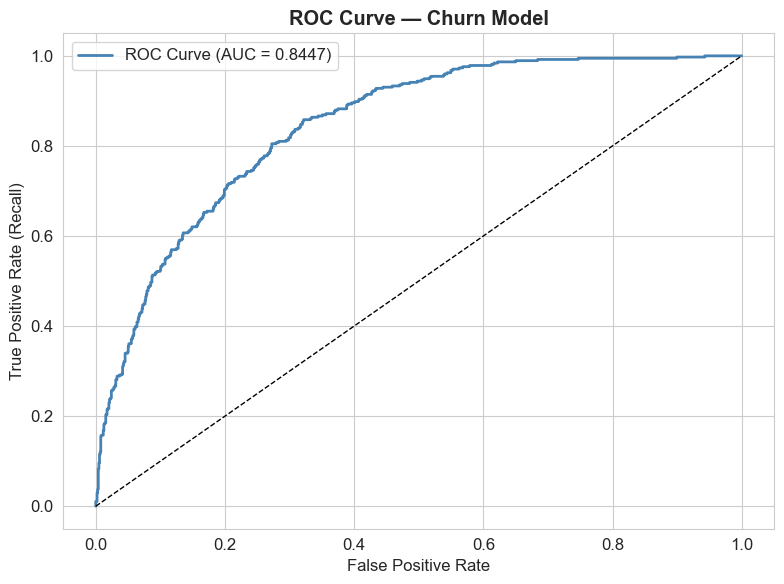

 Threshold  Precision  Recall    F1  Flagged
      0.20      0.472   0.866 0.611      686
      0.25      0.498   0.810 0.617      608
      0.30      0.524   0.746 0.616      532
      0.35      0.559   0.714 0.627      478
      0.40      0.566   0.655 0.607      433
      0.45      0.616   0.596 0.606      362
      0.50      0.656   0.529 0.586      302
      0.55      0.683   0.455 0.546      249
      0.60      0.701   0.377 0.490      201
      0.65      0.727   0.313 0.437      161

BUSINESS IMPACT BY THRESHOLD
t=0.20 | Flagged= 686 | Churners caught=323 | Net benefit = $-5,322
t=0.25 | Flagged= 608 | Churners caught=302 | Net benefit = $-4,308
t=0.30 | Flagged= 532 | Churners caught=279 | Net benefit = $-3,386
t=0.35 | Flagged= 478 | Churners caught=267 | Net benefit = $-2,618
t=0.40 | Flagged= 433 | Churners caught=244 | Net benefit = $-2,316
t=0.45 | Flagged= 362 | Churners caught=222 | Net benefit = $-1,468
t=0.50 | Flagged= 302 | Churners caught=197 | Net benefit = $-918
t

In [51]:
# ── ROC Curve ───────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_prob):.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Model', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# ── Threshold Sweep ─────────────────────────────────────────────────
thresh_range = np.arange(0.2, 0.7, 0.05)
rows = []
for t in thresh_range:
    preds = (y_test_prob >= t).astype(int)
    rows.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, preds), 3),
        'F1':        round(f1_score(y_test, preds), 3),
        'Flagged':   int(preds.sum())
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

# ── Business Simulation ─────────────────────────────────────────────
# Assumptions (adjust to Telsco's real values)
MONTHLY_REVENUE_PER_CUSTOMER = 65   # avg monthly charges
RETENTION_OFFER_COST         = 20   # cost of outreach per customer
RETENTION_SUCCESS_RATE       = 0.40 # 40% of contacted churners retained

total_test_customers = len(y_test)
actual_churners = int(y_test.sum())

print("\nBUSINESS IMPACT BY THRESHOLD")
print("=" * 70)
for _, row in thresh_df.iterrows():
    flagged = int(row['Flagged'])         
    recall   = row['Recall']
    caught   = int(actual_churners * recall)
    saved_rev = caught * RETENTION_SUCCESS_RATE * MONTHLY_REVENUE_PER_CUSTOMER
    campaign_cost = flagged * RETENTION_OFFER_COST
    net_benefit = saved_rev - campaign_cost
    print(f"t={row['Threshold']:.2f} | Flagged={flagged:4d} | "
          f"Churners caught={caught:3d} | "
          f"Net benefit = ${net_benefit:,.0f}")

# 9. Model Interpretation & Business Insights
Key churn drivers and actionable retention strategies are derived from model outputs.

⚠  Quasi-complete separation detected — CIs unreliable for:
                     Odds Ratio  Lower 95% CI  Upper 95% CI  p-value
Online Security_Yes       1.049         1.049         1.049      0.0

                                 Odds Ratio  Lower 95% CI  Upper 95% CI  p-value  Significant
Streaming Movies_Yes                  3.138         2.654         3.709    0.000         True
Streaming TV_Yes                      3.095         2.497         3.835    0.000         True
Tenure Bucket_short                   2.699         1.634         4.460    0.000         True
Device Protection_Yes                 1.536         1.156         2.039    0.003         True
Payment Method_Electronic check       1.413         1.244         1.605    0.000         True
Monthly Charges                       0.915         0.895         0.936    0.000         True
Contract Type_One year                0.489         0.363         0.658    0.000         True
Internet Service_No                   0.224      

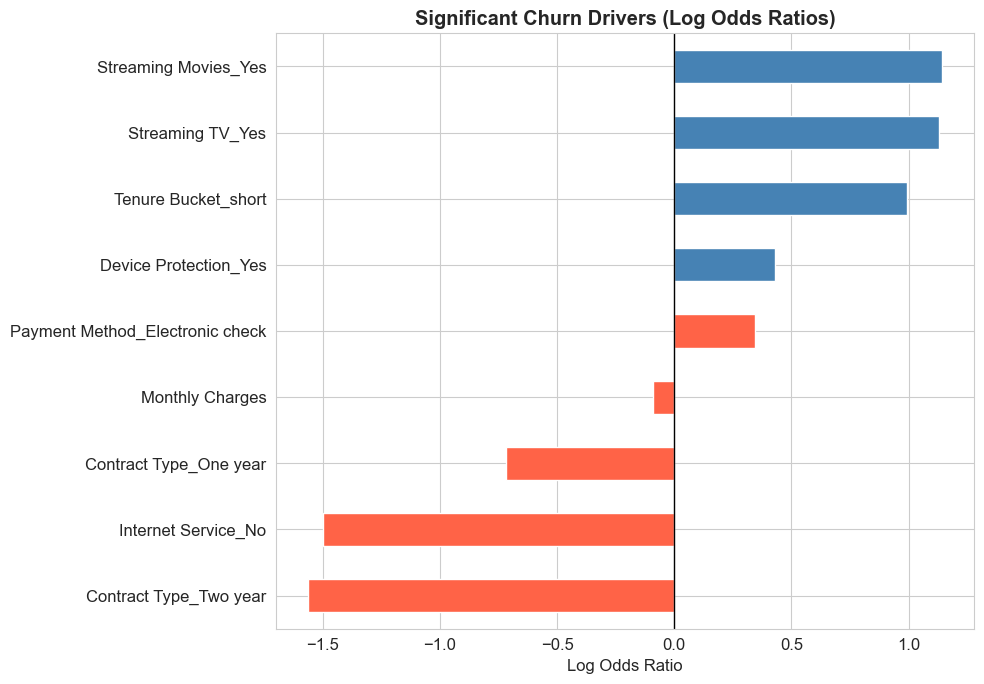

In [52]:
# ── Odds Ratios ─────────────────────────────────────────────────────
# Clip log-odds before exp to prevent overflow when coefficients are
# very large (near-perfect separation). Values beyond ±20 on the
# log-odds scale correspond to ORs > 500M — not interpretable anyway.
LOG_ODDS_CLIP = 20

def safe_exp(series):
    return np.exp(np.clip(series, -LOG_ODDS_CLIP, LOG_ODDS_CLIP))

ci = result.conf_int()
odds_ratios = pd.DataFrame({
    'Odds Ratio':   safe_exp(result.params),
    'Lower 95% CI': safe_exp(ci[0]),
    'Upper 95% CI': safe_exp(ci[1]),
    'p-value':      result.pvalues,
}).drop('const').sort_values('Odds Ratio', ascending=False)

odds_ratios['Significant'] = odds_ratios['p-value'] < 0.05

# Detect degenerate CIs (lower == upper == point estimate).
# This is a sign of quasi-complete separation — statsmodels produces a
# coefficient but the standard error collapses to ~0, making the CI
# identical to the OR. Treat these estimates as unreliable.
degenerate_mask = np.isclose(
    odds_ratios['Lower 95% CI'], odds_ratios['Upper 95% CI']
)
if degenerate_mask.any():
    print("⚠  Quasi-complete separation detected — CIs unreliable for:")
    print(
        odds_ratios[degenerate_mask][
            ['Odds Ratio', 'Lower 95% CI', 'Upper 95% CI', 'p-value']
        ].round(3).to_string()
    )
    print()

sig_clean = odds_ratios[odds_ratios['Significant'] & ~degenerate_mask]
print(sig_clean.round(3).to_string())

# ── Top churn drivers plot ───────────────────────────────────────────
sig_or = sig_clean.copy()
sig_or['log_OR'] = np.log(sig_or['Odds Ratio'])

# Drop any remaining inf/-inf that survived clipping (safety net)
sig_or = sig_or[np.isfinite(sig_or['log_OR'])]

plt.figure(figsize=(10, 7))
colors = ['tomato' if x > 0 else 'steelblue' for x in sig_or['log_OR']]
sig_or['log_OR'].sort_values().plot(kind='barh', color=colors)
plt.axvline(0, color='black', lw=1)
plt.xlabel('Log Odds Ratio')
plt.title('Significant Churn Drivers (Log Odds Ratios)', fontweight='bold')
plt.tight_layout()
plt.show()

# 10. Production Considerations
This section outlines how the model would be deployed, monitored, and retrained in production.

# 11. Final Conclusion
Summary of results, business implications, and next steps.